## Daten geladen

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/global_supply_chain_risk_2026.csv")

df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


## Struktur analysiert

In [2]:
df.shape


(5000, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [4]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


In [5]:
df.columns

Index(['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port',
       'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT',
       'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred'],
      dtype='str')

## Datenqualität geprüft

In [6]:
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

## Datentypen korrigiert

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   str           
 1   Date                       5000 non-null   datetime64[us]
 2   Origin_Port                5000 non-null   str           
 3   Destination_Port           5000 non-null   str           
 4   Transport_Mode             5000 non-null   str           
 5   Product_Category           5000 non-null   str           
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   str           
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_Time_Days   

In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

## Erste Business-Queries

In [10]:
df["Transport_Mode"].value_counts()

Transport_Mode
Air     1320
Sea     1281
Road    1214
Rail    1185
Name: count, dtype: int64

In [11]:
df["Origin_Port"].value_counts().head(10)

Origin_Port
Busan          667
Rotterdam      646
Shanghai       644
Antwerp        635
Dubai          610
Los Angeles    602
Singapore      599
Hamburg        597
Name: count, dtype: int64

## Erste Insights gefunden

In [12]:
df.groupby("Weather_Condition")["Disruption_Occurred"].mean().sort_values(ascending=False)

Weather_Condition
Hurricane    1.000000
Storm        0.795409
Fog          0.480695
Rain         0.419652
Clear        0.369849
Name: Disruption_Occurred, dtype: float64

In [13]:
df.groupby("Transport_Mode")["Lead_Time_Days"].mean()

Transport_Mode
Air      1.644273
Rail    19.954253
Road    16.452306
Sea     39.802966
Name: Lead_Time_Days, dtype: float64

In [14]:
df.groupby("Disruption_Occurred")["Geopolitical_Risk_Score"].mean()

Disruption_Occurred
0    4.262158
1    5.592132
Name: Geopolitical_Risk_Score, dtype: float64

## Visualisierungen / Plots

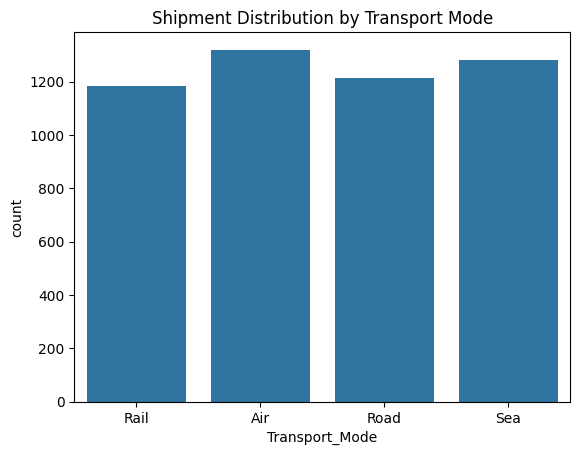

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Transport_Mode")

plt.title("Shipment Distribution by Transport Mode")
plt.show()

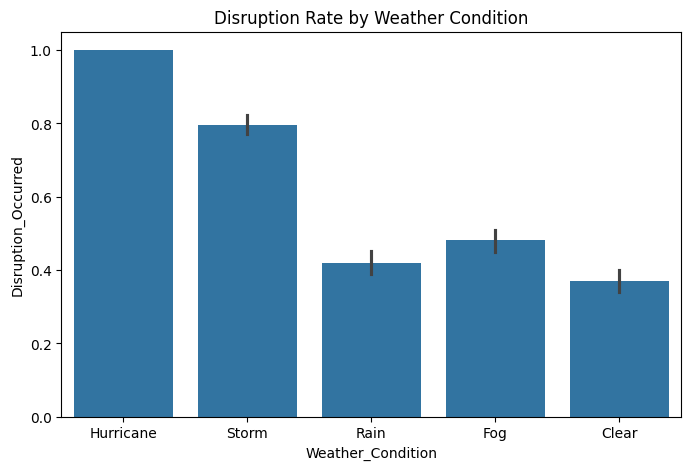

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Weather_Condition", y="Disruption_Occurred")

plt.title("Disruption Rate by Weather Condition")
plt.show()

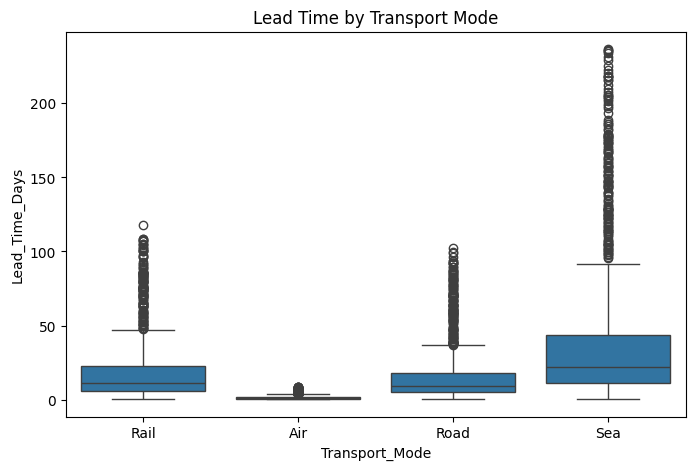

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Transport_Mode", y="Lead_Time_Days")

plt.title("Lead Time by Transport Mode")
plt.show()

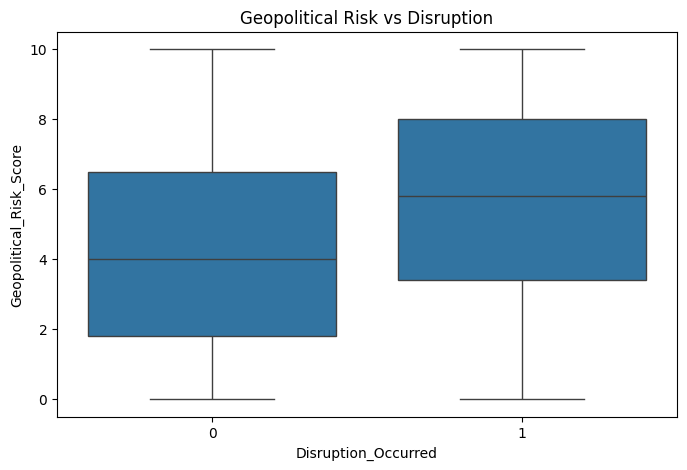

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Disruption_Occurred", y="Geopolitical_Risk_Score")

plt.title("Geopolitical Risk vs Disruption")
plt.show()